In [1]:
import time as clock
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange
from IPython.display import clear_output, display
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

In [2]:
DEVICE = 'cpu'

In [3]:
# configuration of simulator
# and parametrs of reservouir
niter = 100
perm = np.load('perm_2.npy')
nx0, nx1 = perm.shape
nx2 = 1
perm = np.reshape(perm, (nx0, nx1, nx2))
poro = 0.1 + np.zeros((nx0, nx1, nx2))

dx0 = 1.0 / nx0
dx1 = 1.0 / nx1
dx2 = 1.0 / nx2

pwat = 2.0
poil = 4.0
vr = 0.3
kwat = 1.0
koil = 0.3

pmin = 0.0
pmax = 1.0

t_final = 3.0
dt = t_final / niter

# Read from file

In [4]:
# sim_data: pres, swat, soil
sim_data = np.load("data-100-new-two-sigma/sim_100.npy").astype(np.float32)#[sim_nidexes]

pwat_list = np.load("data-100-new-two-sigma/pwat_100.npy").astype(np.float32)
poil_list = np.load("data-100-new-two-sigma/poil_100.npy").astype(np.float32)
kwat_list = np.load("data-100-new-two-sigma/kwat_100.npy").astype(np.float32)
koil_list = np.load("data-100-new-two-sigma/koil_100.npy").astype(np.float32)

In [46]:
niter = 100
nx, ny = 64, 64
t_final = 3.0
dt = t_final / niter
dx, dy = 1 / nx, 1 / ny

indexes_high = np.argwhere(sim_data[:, :, :, :, :, 1] > 0.1)
indexes_low = np.argwhere(sim_data[:, :, :, :, :, 1] > 0)

indexes_low = indexes_low[np.random.randint(0, len(indexes_low),len(indexes_high) // 2)]
indexes = np.vstack([indexes_low, indexes_high])

simulation_data = np.zeros((indexes.shape[0], 3))
for i, row in enumerate(indexes):
    simulation_data[i] = sim_data[row[0], row[1], row[2], row[3], row[4], :3]

x_list = indexes[:, 0] * dx
y_list = indexes[:, 1] * dy
t_list = indexes[:, 3] * dt

pwat_rand = pwat_list[indexes[:, -1]]
poil_rand = poil_list[indexes[:, -1]]
kwat_rand = kwat_list[indexes[:, -1]]
koil_rand = koil_list[indexes[:, -1]]

In [47]:
# rand_indexes_2000 = np.random.randint(0, simulation_data.shape[0], 2000)
# rand_indexes_1000 = np.random.randint(0, simulation_data.shape[0], 1000)
# rand_indexes_500 = np.random.randint(0, simulation_data.shape[0], 500)
# rand_indexes_250 = np.random.randint(0, simulation_data.shape[0], 250)

# np.save('train-indexes-2sigma-2000.npy', rand_indexes_2000)
# np.save('train-indexes-2sigma-1000.npy', rand_indexes_1000)
# np.save('train-indexes-2sigma-500.npy', rand_indexes_500)
# np.save('train-indexes-2sigma-250.npy', rand_indexes_250)
# rand_indexes
# np.save('train-indexes-2sigma-250.npy', rand_indexes)

rand_indexes_2000 = np.load('train-indexes-2sigma-2000.npy')
rand_indexes_1000 = np.load('train-indexes-2sigma-1000.npy')
rand_indexes_500 = np.load('train-indexes-2sigma-500.npy')
rand_indexes_250 = np.load('train-indexes-2sigma-250.npy')

In [48]:
rand_indexes = rand_indexes_250#np.random.randint(0, simulation_data.shape[0], 100)

simulation_data_train = torch.tensor(simulation_data.astype(np.float32))[rand_indexes].requires_grad_(True)

x = torch.tensor(x_list.astype(np.float32))[rand_indexes].requires_grad_(True)
y = torch.tensor(y_list.astype(np.float32))[rand_indexes].requires_grad_(True)
t = torch.tensor(t_list.astype(np.float32))[rand_indexes].requires_grad_(True)


pwat = torch.tensor(pwat_rand.astype(np.float32))[rand_indexes]
poil = torch.tensor(poil_rand.astype(np.float32))[rand_indexes]
kwat = torch.tensor(kwat_rand.astype(np.float32))[rand_indexes]
koil = torch.tensor(koil_rand.astype(np.float32))[rand_indexes]

points = torch.stack((t, x, y, pwat, poil, kwat, koil), -1).requires_grad_(True).to(DEVICE)

In [49]:
points.shape, simulation_data_train.shape

(torch.Size([250, 7]), torch.Size([250, 3]))

In [50]:
class ModifiedPINN(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=128, num_layers=6, output_dim=7):
        super(ModifiedPINN, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.U = nn.Linear(input_dim, hidden_dim)
        self.V = nn.Linear(input_dim, hidden_dim)
        
        self.hidden_layers = nn.ModuleList()
        for i in range(num_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        
        self.pressure_scale = nn.Parameter(torch.ones(1))
        self.saturation_scale = nn.Parameter(torch.ones(2))
        self.velocity_scale = nn.Parameter(torch.ones(4))
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        U = torch.tanh(self.U(x))
        V = torch.tanh(self.V(x))
        
        h = U * V
        
        for i, layer in enumerate(self.hidden_layers):
            h_new = torch.tanh(layer(h))
            if i % 2 == 1 and i > 0:
                h = h + h_new
            else:
                h = h_new
        
        out = self.output_layer(h)
        
        pressure = out[:, 0:1]
        saturation_oil = out[:, 1:2]
        saturation_wat = out[:, 2:3]
        velocities = out[:, 3:7]
        
        pressure = F.softplus(pressure * self.pressure_scale, beta=1, threshold=20)
        
        saturation_oil = torch.sigmoid(saturation_oil * self.saturation_scale[0])
        saturation_wat = torch.sigmoid(saturation_wat * self.saturation_scale[1])
        
        sat_sum = saturation_oil + saturation_wat + 1e-8
        saturation_oil = saturation_oil / sat_sum
        saturation_wat = saturation_wat / sat_sum
        
        velocities = torch.tanh(velocities) * self.velocity_scale
        
        return torch.cat([pressure, saturation_oil, saturation_wat, velocities], dim=1)

model = ModifiedPINN(
   input_dim=7,
   hidden_dim=128,
   num_layers=6,
   output_dim=7
).to(DEVICE)
model.load_state_dict(torch.load('pinn-test4-250-batched-new.pth',map_location='cpu'))

<All keys matched successfully>

# SVM

In [51]:
def check_current_situation_others(svm_model, scaler, t):
    x = np.linspace(0, 1, 100)
    time = t * np.ones(100)
    real_temp = thermal_conductivity_equation([torch.tensor(time), torch.tensor(x)])

    test_points = np.stack((time, x), axis = -1)

    svm_pred = svm_model.predict(scaler.transform(test_points))

    plt.plot(x, svm_pred, label=f'SVM prediction with t = {t}')
    plt.plot(x, real_temp, label=f'Analytical solution with t = {t}')
    plt.grid()
    plt.xlabel('x')
    plt.ylabel(f'T(t={t}, x)')

    plt.plot()
    plt.legend()
    plt.show()
    
def check_current_situation_xgb(xgb, t):
    x = np.linspace(0, 1, 100)
    time = t * np.ones(100)
    real_temp = thermal_conductivity_equation([torch.tensor(time), torch.tensor(x)])

    test_points = np.stack((time, x), axis = -1)

    svm_pred = xgb.predict(test_points)

    plt.plot(x, svm_pred, label=f'SVM prediction with t = {t}')
    plt.plot(x, real_temp, label=f'Analytical solution with t = {t}')
    plt.grid()
    plt.xlabel('x')
    plt.ylabel(f'T(t={t}, x)')

    plt.plot()
    plt.legend()
    plt.show()

In [52]:
X_train = points.cpu().detach().numpy()
y_train = simulation_data_train.cpu().detach().numpy()

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

svr = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")
model_svr = MultiOutputRegressor(svr)
model_svr.fit(X_train, y_train)
# y_pred = svr.predict(X_test_scaled)
# print("MSE:", mean_squared_error(y_test, y_pred))
# print("R^2:", r2_score(y_test, y_pred))

MultiOutputRegressor(estimator=SVR())

In [53]:
# check_current_situation_others(svr, scaler, t=0.0)
# check_current_situation_others(svr, scaler, t=0.01)
# check_current_situation_others(svr, scaler, t=0.02)
# check_current_situation_others(svr, scaler, t=0.03)
# check_current_situation_others(svr, scaler, t=0.04)
# check_current_situation_others(svr, scaler, t=0.05)

# XGBoost

In [54]:
# Example data
xgb_regressor = xgb.XGBRegressor(tree_method='hist', verbosity=2)
xgb_regressor.fit(X_train, y_train)

[06:00:50] INFO: /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (250, 7, 1750).


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [55]:
# check_current_situation_xgb(xgb_regressor, t=0)
# check_current_situation_xgb(xgb_regressor, t=0.01)
# check_current_situation_xgb(xgb_regressor, t=0.02)
# check_current_situation_xgb(xgb_regressor, t=0.03)
# check_current_situation_xgb(xgb_regressor, t=0.04)
# check_current_situation_xgb(xgb_regressor, t=0.05)

# Gaussian Processes Regression

In [56]:
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e+1))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(X_train, y_train)
# y_pred, sigma = gp.predict(X_test, return_std=True)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=10, normalize_y=True)

In [57]:
# check_current_situation_xgb(gp, t=0)
# check_current_situation_xgb(gp, t=0.01)
# check_current_situation_xgb(gp, t=0.02)
# check_current_situation_xgb(gp, t=0.03)
# check_current_situation_xgb(gp, t=0.04)
# check_current_situation_xgb(gp, t=0.05)

# Metrics Computation

In [58]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    median_absolute_error, 
    mean_absolute_percentage_error
)

def evaluate_multidim_models(models_dict, X_test, y_test, device='cpu'):
    results = {}
    
    target_names = ["Pressure", "Soil", "Swat"]
    
    if torch.is_tensor(y_test):
        y_true = y_test.detach().cpu().numpy()
    elif isinstance(y_test, (pd.DataFrame, pd.Series)):
        y_true = y_test.to_numpy()
    else:
        y_true = np.array(y_test)
        
    if y_true.ndim != 2 or y_true.shape[1] != 3:
        raise ValueError(f"y_test must be shape [N, 3], got {y_true.shape}")

    for name, model in models_dict.items():
        y_pred = None
        
        
        if isinstance(model, nn.Module):
            model.eval()
            
            if torch.is_tensor(X_test):
                X_tensor = X_test.to(device)
            elif isinstance(X_test, (pd.DataFrame, pd.Series)):
                X_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
            else:
                X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
            
            with torch.no_grad():
                raw_pred = model(X_tensor)[:, [0, 2, 1]]
                y_pred = raw_pred.cpu().numpy()
                
        else:
            if torch.is_tensor(X_test):
                X_input = X_test.cpu().numpy()
            else:
                X_input = X_test
                
            y_pred = model.predict(X_input)

        if y_pred.shape != y_true.shape:
             raise ValueError(f"Model {name} output shape {y_pred.shape} mismatch with y_test {y_true.shape}")

        model_metrics = {}
        
        for i, label in enumerate(target_names):
            y_t = y_true[:, i]
            y_p = y_pred[:, i]
            
            mse = mean_squared_error(y_t, y_p)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_t, y_p)
            r2 = r2_score(y_t, y_p)
            medae = median_absolute_error(y_t, y_p)
            mape = mean_absolute_percentage_error(y_t, y_p)
            
            model_metrics[f"{label}_MSE"] = mse
            model_metrics[f"{label}_RMSE"] = rmse
            model_metrics[f"{label}_MAE"] = mae
            model_metrics[f"{label}_R2"] = r2
            model_metrics[f"{label}_MedAE"] = medae
            model_metrics[f"{label}_MAPE"] = mape

        results[name] = model_metrics

    df_results = pd.DataFrame(results)
    
    return df_results

In [60]:
class DecoupledPINN(nn.Module):
    def __init__(self, input_dim=7):
        super().__init__()
        
        self.net_pressure = nn.Sequential(
            nn.Linear(input_dim, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1) # Output Pressure only
        )
        
        self.net_saturation = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ELU(),
            nn.Linear(50, 50),
            nn.ELU(),
            nn.Linear(50, 50),
            nn.ELU(),
            nn.Linear(50, 1)
        )
        
        self.net_velocity = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.Tanh(),
            nn.Linear(30, 4)
        )

    def forward(self, x):
        pres = torch.nn.functional.softplus(self.net_pressure(x))
        sw = torch.sigmoid(self.net_saturation(x))
        vel = self.net_velocity(x)
        
        so = 1.0 - sw
        
        return torch.cat([pres, so, sw, vel], dim=1)
# model = DecoupledPINN().to(DEVICE)
# model.load_state_dict(torch.load('/Users/kirill/Downloads/pinn-fullbatch-best-500.pth',map_location='cpu'))
# /Users/kirill/Downloads/pinn-fullbatch-best-100-doubled.pth



# best --------------------------------------------------------------
# model.load_state_dict(torch.load('/Users/kirill/Downloads/pinn-fullbatch-best-250-doubled.pth',map_location='cpu'))
# model.load_state_dict(torch.load('/Users/kirill/Downloads/pinn-fullbatch-best-100-sigmoid-2.pth',map_location='cpu'))
# model.load_state_dict(torch.load('/Users/kirill/Downloads/pinn-fullbatch-best-100-sigmoid-2-2.pth',map_location='cpu'))


class DecoupledPINN2(nn.Module):
    def __init__(self, input_dim=7):
        super().__init__()
        
        self.net_pressure = nn.Sequential(
            nn.Linear(input_dim, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1) # Output Pressure only
        )
        
        
        self.net_saturation = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ELU(), # ELU or SELU often works better for shocks than Tanh
            nn.Linear(50, 50),
            nn.ELU(),
            nn.Linear(50, 50),
            nn.ELU(),
            nn.Linear(50, 1) # Output Saturation only
        )
        
        
        self.net_velocity = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 4)
        )

    def forward(self, x):
        
        pres = torch.sigmoid(self.net_pressure(x))
        sw = torch.sigmoid(self.net_saturation(x))
        vel = self.net_velocity(x)
        
        so = 1.0 - sw
        
        return torch.cat([pres, so, sw, vel], dim=1)

class DecoupledPINN3(nn.Module):
    def __init__(self, input_dim=7):
        super().__init__()
        
        self.net_pressure = nn.Sequential(
            nn.Linear(input_dim, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1),
            nn.Sigmoid(),# Output Pressure only
        )
        
        
        self.net_saturation = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ELU(),
            nn.Linear(50, 50),
            nn.ELU(),
            nn.Linear(50, 50),
            nn.ELU(),
            nn.Linear(50, 1)
        )
        
        self.net_velocity = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 4)
        )

    def forward(self, x):
        pres = self.net_pressure(x)
        sw = torch.sigmoid(self.net_saturation(x))
        vel = self.net_velocity(x)
        
        so = 1.0 - sw
        
        return torch.cat([pres, so, sw, vel], dim=1)

In [61]:
indexes_high = np.argwhere(sim_data[:, :, :, :, :, 1] > 0.25)
indexes_low = np.argwhere(sim_data[:, :, :, :, :, 1] > 0.0)

indexes_low = indexes_low[np.random.randint(0, len(indexes_low),len(indexes_high) // 2)]
indexes = indexes_high#np.vstack([indexes_low, indexes_high])

simulation_data = np.zeros((indexes.shape[0], 3))
for i, row in enumerate(indexes):
    simulation_data[i] = sim_data[row[0], row[1], row[2], row[3], row[4], :3]

x_list = indexes[:, 0] * dx
y_list = indexes[:, 1] * dy
t_list = indexes[:, 3] * dt

pwat_rand = pwat_list[indexes[:, -1]]
poil_rand = poil_list[indexes[:, -1]]
kwat_rand = kwat_list[indexes[:, -1]]
koil_rand = koil_list[indexes[:, -1]]

rand_indexes = np.random.randint(0, simulation_data.shape[0], 1000)
simulation_data_train = torch.tensor(simulation_data.astype(np.float32)).requires_grad_(True)[rand_indexes]

x = torch.tensor(x_list.astype(np.float32)).requires_grad_(True)[rand_indexes]
y = torch.tensor(y_list.astype(np.float32)).requires_grad_(True)[rand_indexes]
t = torch.tensor(t_list.astype(np.float32)).requires_grad_(True)[rand_indexes]


pwat = torch.tensor(pwat_rand.astype(np.float32))[rand_indexes]
poil = torch.tensor(poil_rand.astype(np.float32))[rand_indexes]
kwat = torch.tensor(kwat_rand.astype(np.float32))[rand_indexes]
koil = torch.tensor(koil_rand.astype(np.float32))[rand_indexes]

points = torch.stack((t, x, y, pwat, poil, kwat, koil), -1).requires_grad_(True).to(DEVICE)

In [62]:
# from diffusion_equation import compute_solution
# pwat=1.5
# poil=2.0
# kwat=1.5
# koil = 0.3

# perm = np.load('perm_2.npy')
# nx0, nx1 = perm.shape
# nx2 = 1
# perm = np.reshape(perm, (nx0, nx1, nx2))
# poro = 0.1 + np.zeros((nx0, nx1, nx2))

# dx0 = 1.0 / nx0
# dx1 = 1.0 / nx1
# dx2 = 1.0 / nx2
# vr = 0.3

# if isinstance(pwat, float):
#     pwat_list = pwat * np.ones(64 * 64)
#     poil_list = poil * np.ones(64 * 64)
#     kwat_list = kwat * np.ones(64 * 64)
#     koil_list = koil * np.ones(64 * 64)

# pmin = 0.0
# pmax = 1.0

# dt = 0.21e-1
# niter = 100


# pres, swat, soil = compute_solution(perm, poro,
#                                     dx0, dx1, dx2, dt * niter, niter,
#                                     pwat, kwat, poil, koil, vr,
#                                     pmin=0.0, pmax=1.0)

# time_for_model = (niter * dt) * torch.ones(64 * 64)
# x_for_model = dx0 * torch.arange(64)
# y_for_model = dx1 * torch.arange(64)
# cartesian_points = torch.cartesian_prod(x_for_model, y_for_model)

# X_test = np.stack((
#     time_for_model, 
#     cartesian_points[:, 0], 
#     cartesian_points[:, 1],
#     pwat * np.ones(64 * 64),
#     poil * np.ones(64 * 64),
#     kwat * np.ones(64 * 64),
#     koil * np.ones(64 * 64)
# ), -1)  
# y_test = np.stack(
#     (
#        pres[:, :, :, -1].reshape(-1, 1)[:, 0], 
#         swat[:, :, :, -1].reshape(-1, 1)[:, 0], 
#         soil[:, :, :, -1].reshape(-1, 1)[:, 0]
#     ), -1
# )

In [63]:
X_test = points.cpu().detach().numpy()
y_test = simulation_data_train.cpu().detach().numpy()[:, [0, 1, 2]]

In [64]:
# 500, pinn-fullbatch-best-500.pth
# 8

# 1000, pinn-fullbatch-best-1000.pth
# 4

# 2000, pinn-fullbatch-best-2000.pth
# 4, 7

In [66]:
X_train.shape

(250, 7)

In [67]:
# model = DecoupledPINN().to(DEVICE)
# model.load_state_dict(torch.load('pinn-fullbatch-best-2000-4.pth',map_location='cpu'))


# model = DecoupledPINN2().to(DEVICE)
# model.load_state_dict(torch.load('pinn-fullbatch-best-250-new-dec-5.pth',map_location='cpu'))

# model = DecoupledPINN3().to(DEVICE)
# model.load_state_dict(torch.load('/pinn-fullbatch-best-100-new2-dec.pth',map_location='cpu'))

my_models = {
    'PINN': model,
    'XGB': xgb_regressor,
    'SVM': model_svr,
    'GP': gp
}

df_metrics = evaluate_multidim_models(my_models, X_test, y_test)
df_metrics

,PINN,XGB,SVM,GP
Pressure_MSE,0.000216,0.000118,0.003002,0.001481
Pressure_RMSE,0.014698,0.010851,0.054788,0.038480
Pressure_MAE,0.009069,0.004329,0.045681,0.031396
Pressure_R2,0.223216,0.576638,-9.793596,-4.324472
Pressure_MedAE,0.005658,0.002053,0.041038,0.028146
Pressure_MAPE,0.009360,0.004448,0.046569,0.032067
Soil_MSE,0.003666,0.002173,0.008200,0.005955
Soil_RMSE,0.060548,0.046612,0.090555,0.077171
Soil_MAE,0.042981,0.035889,0.074315,0.063016
Soil_R2,0.339155,0.608356,-0.478158,-0.073518


# Number of training points to metrcis

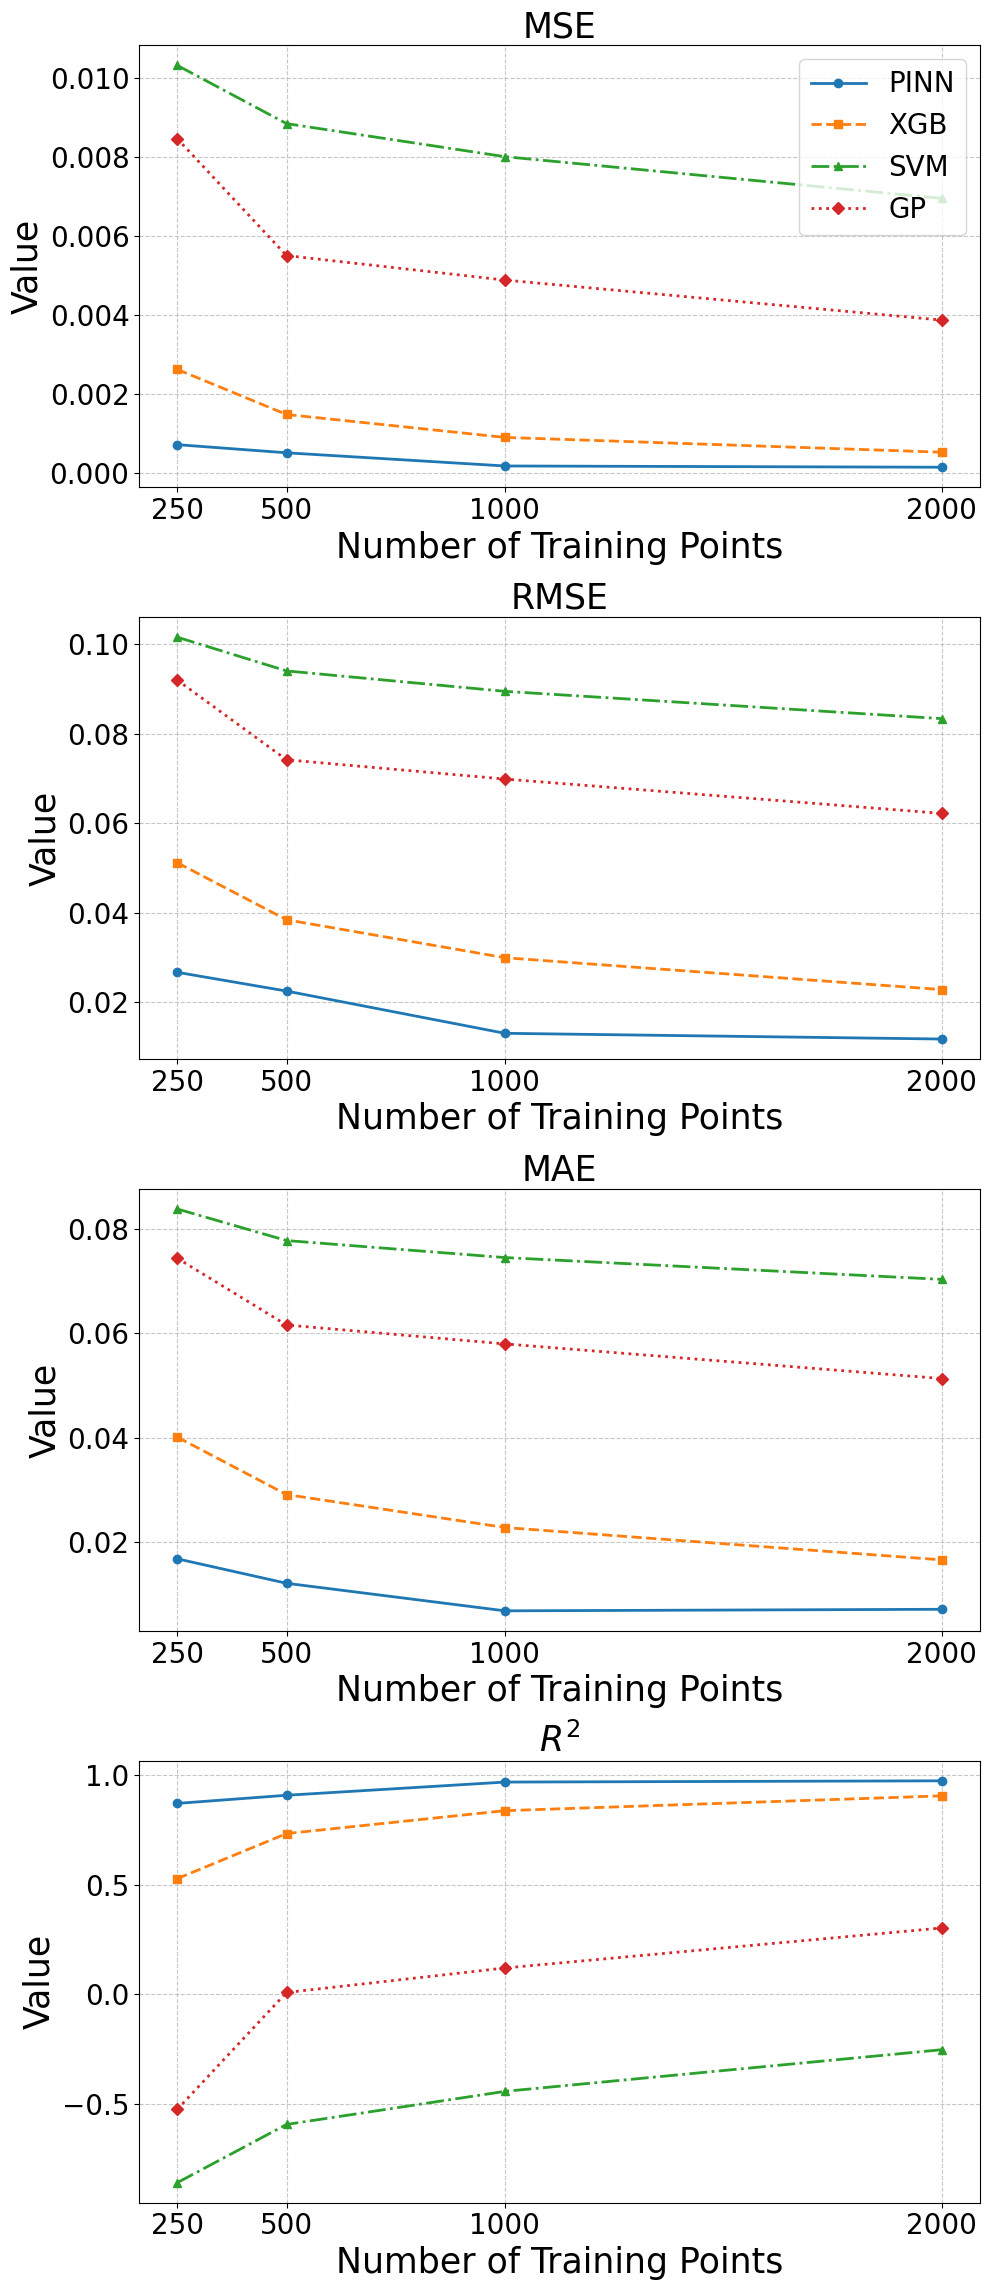

In [82]:
import matplotlib.pyplot as plt
import numpy as np


n_points = [250, 500, 1000, 2000]

models = ['PINN', 'XGB', 'SVM', 'GP']


raw_data = {
    'MSE': [
        [0.000709, 0.000503, 0.000169, 0.000137], # PINN
        [0.002615, 0.001474, 0.000893, 0.000518], # XGB
        [0.010322, 0.008847, 0.008009, 0.006953], # SVM
        [0.008462, 0.005502, 0.004881, 0.003867]  # GP
    ],
    'RMSE': [
        [0.026626, 0.022433, 0.012982, 0.011700], # PINN
        [0.051136, 0.038387, 0.029891, 0.022762], # XGB
        [0.101598, 0.094061, 0.089492, 0.083385], # SVM
        [0.091991, 0.074178, 0.069867, 0.062184]  # GP
    ],
    'MAE': [
        [0.016746, 0.012058, 0.006773, 0.007069], # PINN
        [0.040083, 0.029071, 0.022752, 0.016549], # XGB
        [0.083834, 0.077788, 0.074525, 0.070343], # SVM
        [0.074377, 0.061589, 0.057966, 0.051326]  # GP
    ],
    'R2': [
        [0.872334, 0.909376, 0.969650, 0.975347], # PINN
        [0.529101, 0.734643, 0.839104, 0.906700], # XGB
        [-0.858814, -0.593242, -0.442230, -0.252100], # SVM
        [-0.523889, 0.009142, 0.120955, 0.303663] # GP
    ]
    
styles = {
    'PINN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'XGB':  {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'SVM':  {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'GP':   {'color': '#d62728', 'marker': 'D', 'linestyle': ':'}
}

metrics_list = ['MSE', 'RMSE', 'MAE', 'R2']

fig, axes = plt.subplots(4, 1, figsize=(10, 23))
axes = axes.flatten() # Flatten to easy indexing

for i, metric in enumerate(metrics_list):

    
    ax = axes[i]
    
    metric_values = raw_data[metric]
    
    for j, model_name in enumerate(models):
        y_values = metric_values[j]
        style = styles[model_name]
        
        ax.plot(n_points, y_values, label=model_name, 
                linewidth=2, markersize=6, **style)
    ax.tick_params(axis='both', which='major', labelsize=20)
    if metric == 'R2':
        ax.set_title(r'$R^2$', fontsize=25)
    else:
        ax.set_title(f'{metric}', fontsize=25)
    ax.set_xlabel('Number of Training Points', fontsize=25)
    ax.set_ylabel('Value', fontsize=25)
    ax.grid(True, which='both', linestyle='--', alpha=0.7)
    
    ax.set_xticks(n_points)
    
    if i == 0:
        ax.legend(loc='best', fontsize=20, frameon=True)

plt.tight_layout()

plt.savefig('metric_dependencies_very_big.png')
plt.show()